# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore and understand the characteristics of the preprocessed water quality dataset. Exploratory Data Analysis (EDA) helps identify relationships among features, understand data distributions, detect outliers, analyze correlations, and generate insights that support feature engineering and machine learning model development.

## Theory

Exploratory Data Analysis (EDA) is a statistical approach used to summarize and visualize datasets before building machine learning models. Through descriptive statistics and graphical analysis, EDA helps understand the structure of the data, identify anomalies, detect patterns, evaluate feature relationships, and support informed preprocessing and modeling decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset_path = "../../01_Datasets/Preprocessed Dataset/Master_Dataset_Preprocessed.csv"

df = pd.read_csv(
    dataset_path,
    low_memory=False
)

print("Preprocessed Dataset Loaded Successfully!")

Preprocessed Dataset Loaded Successfully!


In [3]:
print("Dataset Shape:")

print(df.shape)

Dataset Shape:
(1072718, 10)


In [4]:
df.head()

,pH,Temperature,Turbidity,Total Dissolved Solids,Conductivity,Dissolved Oxygen,Nitrate,Chloride,Target,WQI
0,7.42,16.88,0.25,306.7,1486.1,7.41,5.561756,174.687793,Good,NaN
1,8.18,20.55,0.87,84.3,476.3,6.04,5.561756,174.687793,Moderate,NaN
2,5.58,26.25,1.99,676.7,479.9,6.71,5.561756,174.687793,Poor,NaN
3,7.93,30.15,0.06,852.9,713.5,3.24,5.561756,174.687793,Poor,NaN
4,8.37,12.32,3.37,161.2,1702.6,6.83,5.561756,174.687793,Poor,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1072718 entries, 0 to 1072717
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   pH                      1072718 non-null  float64
 1   Temperature             1072718 non-null  float64
 2   Turbidity               1072718 non-null  float64
 3   Total Dissolved Solids  1072718 non-null  float64
 4   Conductivity            1072718 non-null  float64
 5   Dissolved Oxygen        49229 non-null    float64
 6   Nitrate                 1072718 non-null  float64
 7   Chloride                1072718 non-null  float64
 8   Target                  1024678 non-null  object 
 9   WQI                     46369 non-null    float64
dtypes: float64(9), object(1)
memory usage: 81.8+ MB


In [6]:
df.describe()

,pH,Temperature,Turbidity,Total Dissolved Solids,Conductivity,Dissolved Oxygen,Nitrate,Chloride,WQI
count,1.072718e+06,1.072718e+06,1.072718e+06,1.072718e+06,1.072718e+06,49229.000000,1.072718e+06,1.072718e+06,46369.000000
mean,7.554728e+00,1.938302e+01,4.780637e-01,2.648764e+02,4.195952e+02,8.130753,6.040630e+00,1.812231e+02,29.542293
std,1.000300e+00,1.106506e+01,9.117025e-01,1.510279e+02,1.889201e+02,1.138848,3.028788e+00,6.314547e+01,18.375820
min,3.000000e-01,0.000000e+00,1.410000e-14,1.064299e-02,0.000000e+00,0.000000,0.000000e+00,2.941350e+01,0.524595
25%,6.952909e+00,1.174608e+01,4.214063e-02,1.381923e+02,2.876609e+02,7.897736,4.060051e+00,1.405665e+02,22.762953
50%,7.500000e+00,1.697046e+01,2.000475e-01,2.648764e+02,3.959920e+02,7.987445,5.561756e+00,1.746878e+02,29.055156
75%,8.062377e+00,2.468364e+01,5.623331e-01,3.886705e+02,5.222191e+02,8.184740,7.417626e+00,2.117792e+02,33.683065
max,1.397159e+01,2.430051e+02,1.996778e+01,1.197000e+03,9.272000e+03,19.918926,7.307293e+01,1.430549e+03,1834.549110


In [7]:
import matplotlib.pyplot as plt

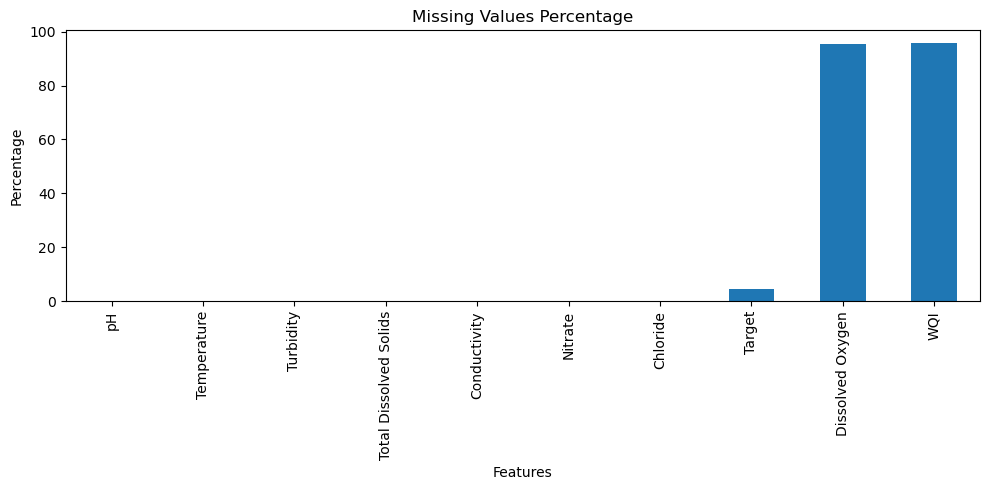

In [8]:
missing_percentage = (df.isnull().sum()/len(df))*100

missing_percentage.sort_values().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Missing Values Percentage")

plt.ylabel("Percentage")

plt.xlabel("Features")

plt.tight_layout()

plt.show()

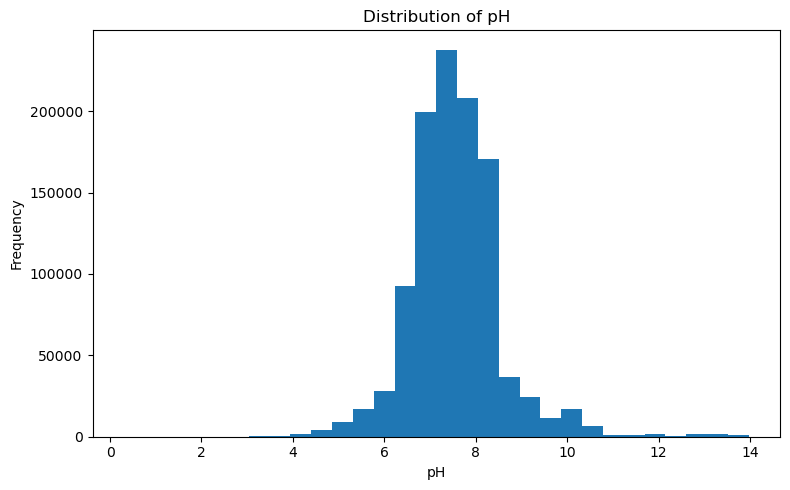

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["pH"], bins=30)

plt.title("Distribution of pH")

plt.xlabel("pH")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

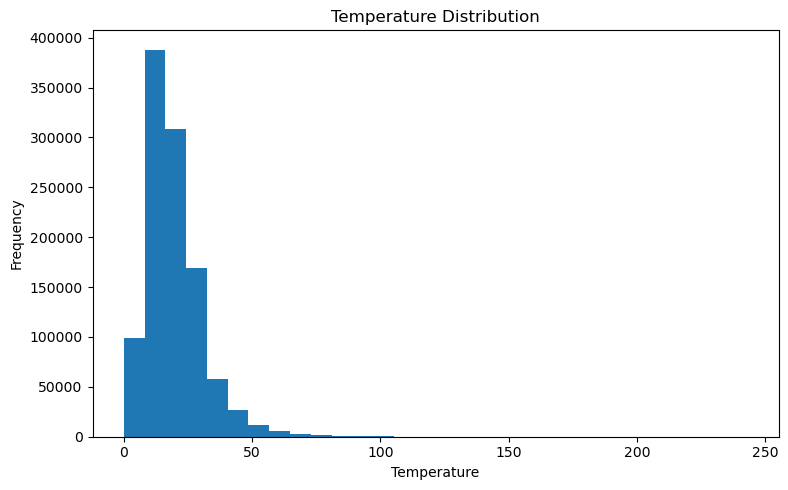

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df["Temperature"], bins=30)

plt.title("Temperature Distribution")

plt.xlabel("Temperature")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

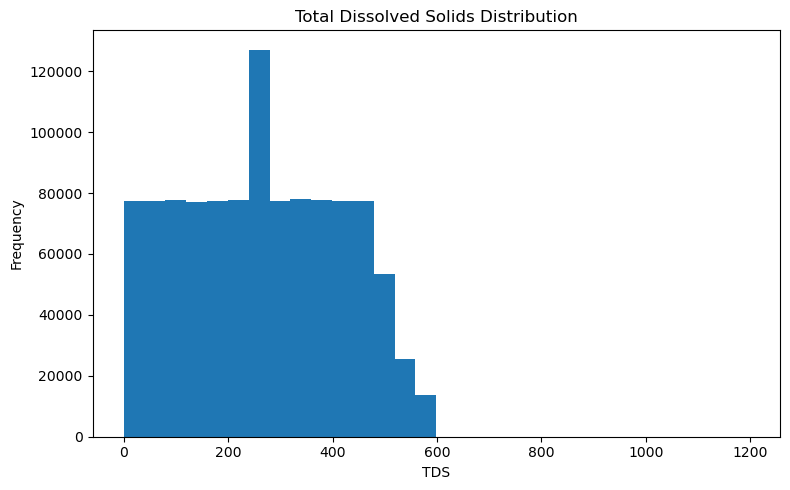

In [11]:
plt.figure(figsize=(8,5))

plt.hist(df["Total Dissolved Solids"], bins=30)

plt.title("Total Dissolved Solids Distribution")

plt.xlabel("TDS")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

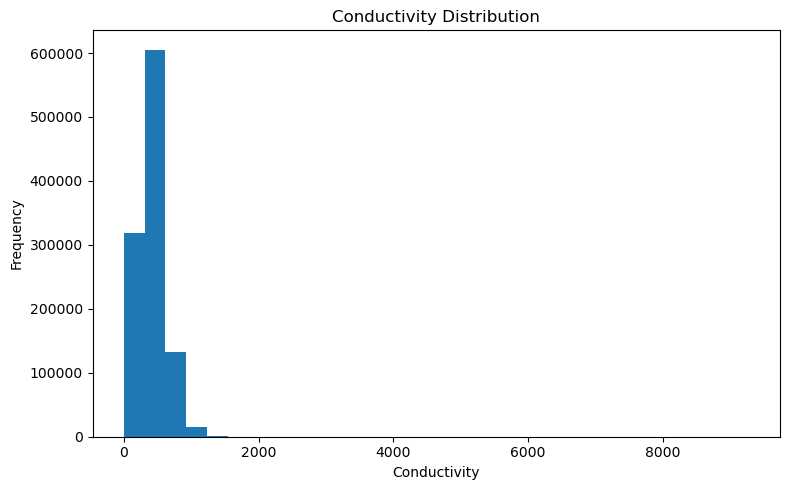

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df["Conductivity"], bins=30)

plt.title("Conductivity Distribution")

plt.xlabel("Conductivity")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [13]:
correlation_matrix = df.select_dtypes(include=["float64"]).corr()

correlation_matrix

,pH,Temperature,Turbidity,Total Dissolved Solids,Conductivity,Dissolved Oxygen,Nitrate,Chloride,WQI
pH,1.000000,0.063684,-0.047124,-0.006774,-0.066113,0.102015,-0.024808,-0.022427,0.597604
Temperature,0.063684,1.000000,-0.001662,0.000265,-0.017610,-0.282253,-0.004964,-0.002457,0.224084
Turbidity,-0.047124,-0.001662,1.000000,0.039883,0.015254,-0.276768,0.067396,0.082039,NaN
Total Dissolved Solids,-0.006774,0.000265,0.039883,1.000000,0.004081,-0.154698,0.028141,0.033819,NaN
Conductivity,-0.066113,-0.017610,0.015254,0.004081,1.000000,0.082262,0.003229,0.001894,0.116171
Dissolved Oxygen,0.102015,-0.282253,-0.276768,-0.154698,0.082262,1.000000,0.043296,NaN,-0.214487
Nitrate,-0.024808,-0.004964,0.067396,0.028141,0.003229,0.043296,1.000000,0.064346,-0.264048
Chloride,-0.022427,-0.002457,0.082039,0.033819,0.001894,NaN,0.064346,1.000000,NaN
WQI,0.597604,0.224084,NaN,NaN,0.116171,-0.214487,-0.264048,NaN,1.000000


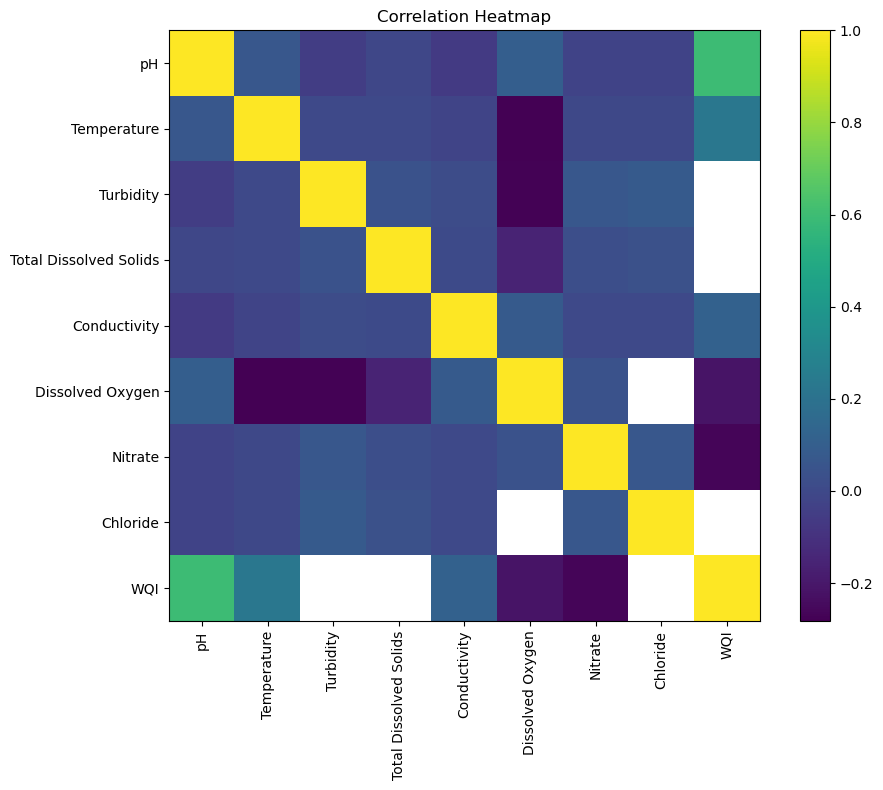

In [14]:
plt.figure(figsize=(10,8))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

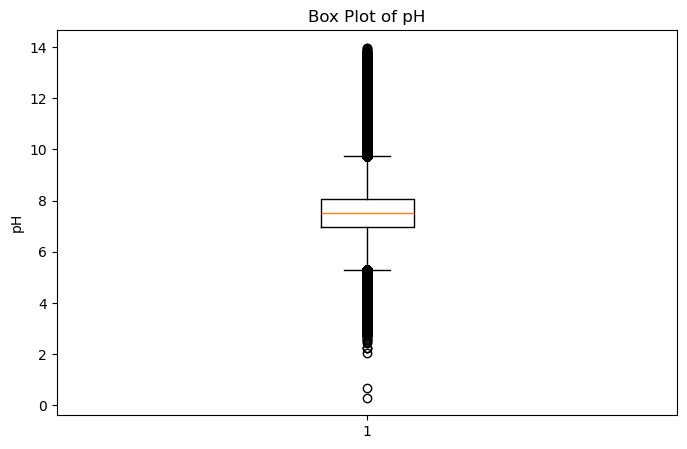

In [15]:
plt.figure(figsize=(8,5))

plt.boxplot(df["pH"].dropna())

plt.title("Box Plot of pH")

plt.ylabel("pH")

plt.show()

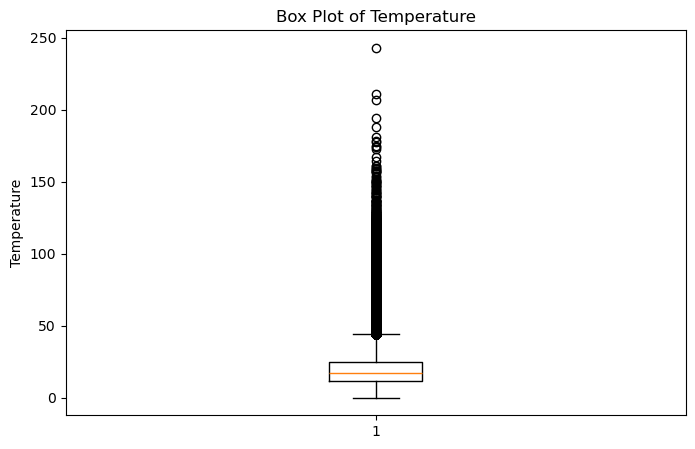

In [16]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Temperature"].dropna())

plt.title("Box Plot of Temperature")

plt.ylabel("Temperature")

plt.show()

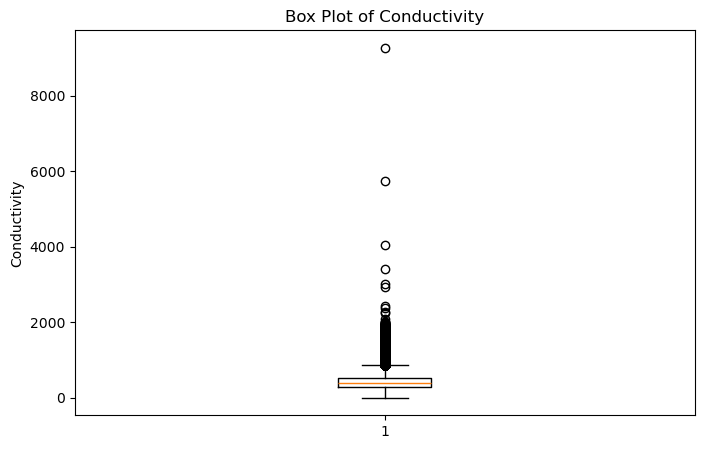

In [17]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Conductivity"].dropna())

plt.title("Box Plot of Conductivity")

plt.ylabel("Conductivity")

plt.show()

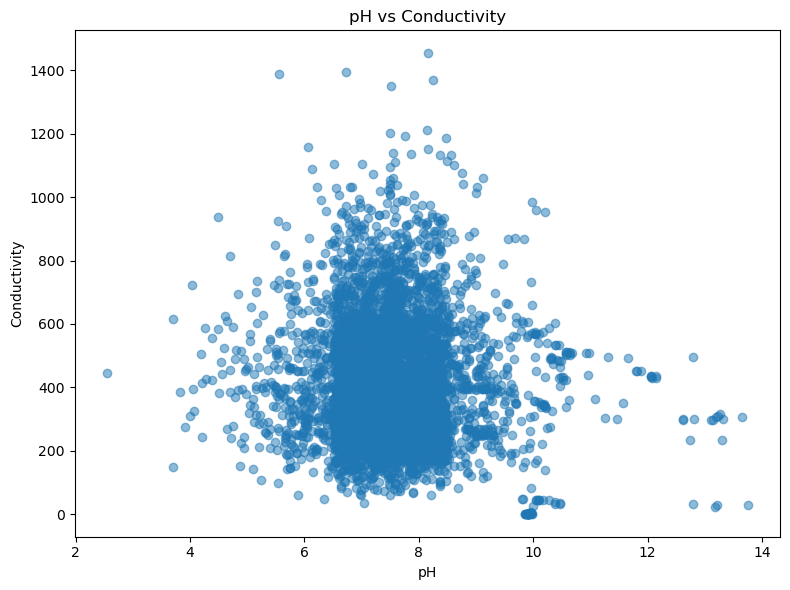

In [18]:
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(8,6))

plt.scatter(
    sample_df["pH"],
    sample_df["Conductivity"],
    alpha=0.5
)

plt.xlabel("pH")

plt.ylabel("Conductivity")

plt.title("pH vs Conductivity")

plt.tight_layout()

plt.show()

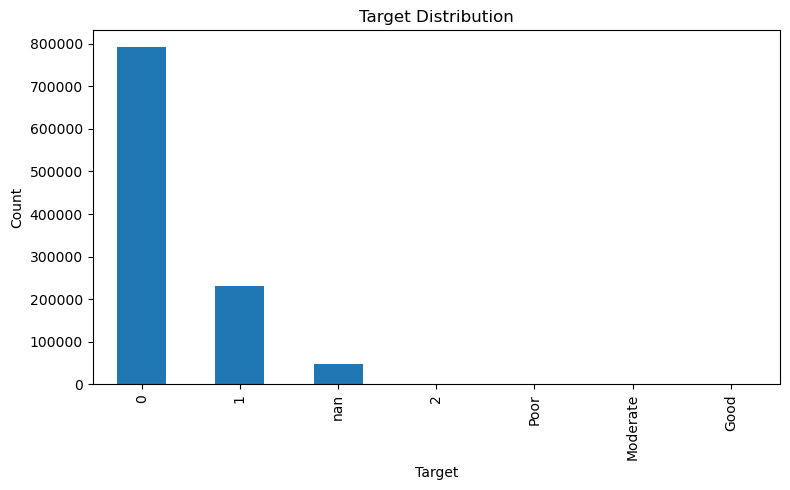

In [19]:
df["Target"].value_counts(dropna=False).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Target Distribution")

plt.xlabel("Target")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

In [27]:
import os

# Folder where all EDA figures will be stored
figure_folder = "../../08_Documentation/Figures"

# Create folder if it does not exist
os.makedirs(figure_folder, exist_ok=True)

print("Figure folder is ready!")

print("Location:", os.path.abspath(figure_folder))

Figure folder is ready!
Location: D:\Major Project\08_Documentation\Figures


# Conclusion

Exploratory Data Analysis (EDA) was performed on the preprocessed water quality dataset to better understand its characteristics. The analysis included missing value visualization, statistical summaries, feature distributions, box plots, scatter plots, and correlation analysis. These observations provide valuable insights into the dataset and help in selecting appropriate features for machine learning model development.